# Braincancer in *silico* modelling - the road map ahead

Christos Panagiotis Papanikas, Eleftheria Tzamali, Dimitris M. Manias, Eleftherios Ioannou, Dimitra Flouri, Soheil Soltani, Vangelis Sakkalis, Haralampos Hatzikirou and Vasileios Vavourakis.

**Python code for the cluster analysis**
V1.0.0, 28-04-2026<br>
****



In [1]:
# import sys
# !{sys.executable} -m pip install umap-learn

In [2]:
import os
import sys
sys.dont_write_bytecode = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import umap
import plotly.graph_objects as go
import cancer_dataset_module as module

data_dir = 'datasets'
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18


---
# Classification on clusters

In [3]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

## Set Dataset

In [4]:
data_org = pd.read_csv(os.path.join(data_dir, 'Main_Dataset.csv'), encoding='utf-8')

#### Split to 4-5-year windows

In [5]:
year_ranges = [(2000, 2004), (2005, 2009), (2010, 2013), (2014, 2017), (2018, 2021), (2022, 2025)]
data_org = module.add_opacity_columns(data_org, year_ranges)

#### Split to datasets of Mathematical Methods

In [6]:
data_ODEs              = data_org.loc[data_org['label_ODEs']==1].reset_index(drop=True)
data_PDEs              = data_org.loc[data_org['label_PDEs']==1].reset_index(drop=True)
data_Agent_based       = data_org.loc[data_org['label_Agent_Based_Models']==1].reset_index(drop=True)
data_Hybrid_Multiscale = data_org.loc[data_org['label_Hybrid_Multiscale']==1].reset_index(drop=True)
data_ML_AI             = data_org.loc[data_org['label_ML_AI']==1].reset_index(drop=True)

### Select Dataset for cluster analysis

In [7]:
################### Select full dataset or from mathematical methods ######################
data = data_org.copy()
# data = data_ODEs.copy()
# data = data_PDEs.copy()
# data = data_Agent_based.copy()
# data = data_Hybrid_Multiscale.copy()
# data = data_ML_AI.copy()

# data_2000_2004 = data[(data['Year'] >= 2000) & (data['Year'] <= 2004)].reset_index(drop=True)
# data_2005_2009 = data[(data['Year'] >= 2005) & (data['Year'] <= 2009)].reset_index(drop=True)
# data_2010_2013 = data[(data['Year'] >= 2010) & (data['Year'] <= 2013)].reset_index(drop=True)
# data_2014_2017 = data[(data['Year'] >= 2014) & (data['Year'] <= 2017)].reset_index(drop=True)
# data_2018_2021 = data[(data['Year'] >= 2018) & (data['Year'] <= 2021)].reset_index(drop=True)
# data_2022_2025 = data[(data['Year'] >= 2022) & (data['Year'] <= 2025)].reset_index(drop=True)

####################### Select full dataset or from year range ###########################
#data = data_2000_2004.copy()
#data = data_2005_2009.copy()
#data = data_2010_2013.copy()
#data = data_2014_2017.copy()
#data = data_2018_2021.copy()
#data = data_2022_2025s.copy()
print(data.shape[0], 'publications have been selected')

558 publications have been selected


----
# Histograms

In [8]:
percentage = False

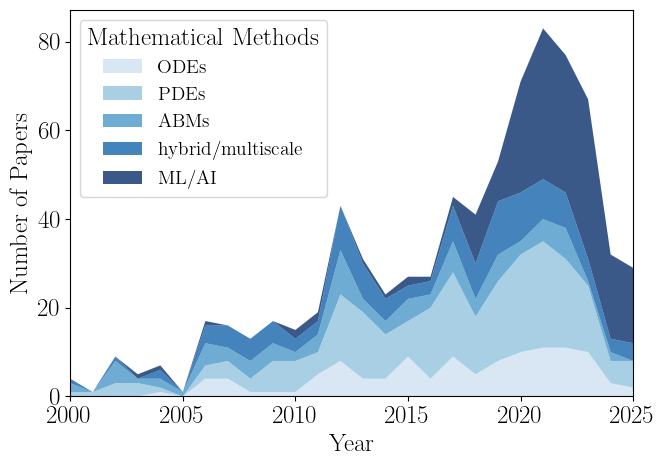

In [9]:
import matplotlib.ticker as ticker

# Extract relevant columns (Year and flags related to mathematical methods)
methods_columns = [
    'label_ODEs', 'label_PDEs', 'label_Agent_Based_Models',
    'label_Hybrid_Multiscale', 'label_ML_AI'
]

methods_data = data[['Year'] + methods_columns]

# Group by year and sum the occurrences of each method
methods_per_year = methods_data.groupby('Year').sum()/data.shape[0]*100 if percentage else methods_data.groupby('Year').sum()

# Create shades of green for each label
colors = plt.cm.Blues([0.2, 0.4,0.6, 0.8, 1.0])

custom_labels_MM = ['ODEs', 'PDEs', 'ABMs', 'hybrid/multiscale', 'ML/AI']

# Create a streamgraph (stacked area plot) for custom data technologies with shades of green
plt.figure(figsize=(7, 5))
plt.stackplot(
    methods_per_year.index, 
    methods_per_year.T, 
    labels=custom_labels_MM,
    colors=colors,
    alpha=0.8,
    # baseline='sym'  # Balanced streamgraph
)
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18
plt.legend(custom_labels_MM, title = 'Mathematical Methods',loc="upper left", ncol=1, fontsize=14)
# plt.legend(loc='upper left', title="Mathematical Methods")
# plt.title('Mathematical Methods Distribution Over Time')
plt.xlabel('Year')
plt.ylabel('\% of total volume') if percentage else plt.ylabel('Number of Papers')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # Major ticks every 5 years
plt.xlim(2000,2025)

# Generate ticks starting from 2000 with a step of 5 years
ticks = [2000, 2005, 2010, 2015, 2020, 2025]

# Set the x-ticks to the calculated range
ax.set_xticks(ticks)

plt.tight_layout()

plt.savefig(f'{output_dir}/Streamgraph_mathematical_methods_percent_vs_time.pdf',dpi=400, bbox_inches='tight') if percentage else plt.savefig(f'{output_dir}/Streamgraph_mathematical_methods_vs_time.pdf',dpi=400, bbox_inches='tight')
plt.show()

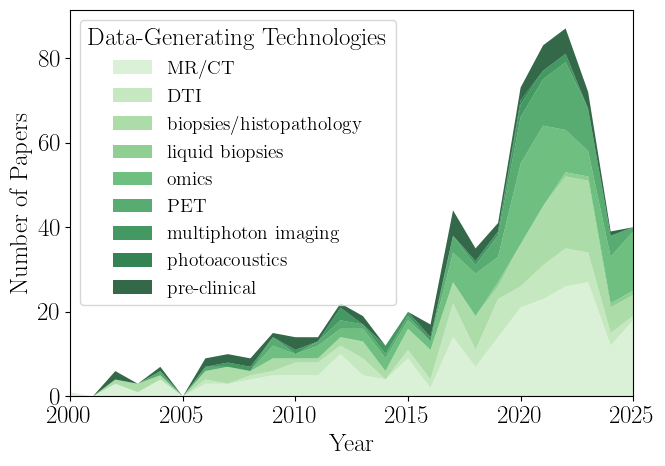

In [10]:
# Extract the specific data technology columns the user requested
custom_data_tech_columns = [
    'label_MR_CT', 'label_DTI', 'label_Biopsies_Histopathology', 
    'label_Liquid_Biopsies', 'label_Omics', 'label_PET', 
    'label_Multiphoton_Imaging', 'label_Photoacoustics','label_in_vitro_mouse'
]
custom_data_tech_data = data[['Year'] + custom_data_tech_columns]

# Group by year and sum the occurrences of each custom data technology
custom_data_tech_per_year = custom_data_tech_data.groupby('Year').sum()/data.shape[0]*100 if percentage else custom_data_tech_data.groupby('Year').sum()

# Create shades of green for each label
colors = plt.cm.Greens([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Create a streamgraph (stacked area plot) for custom data technologies with shades of green
plt.figure(figsize=(7, 5))
plt.stackplot(
    custom_data_tech_per_year.index, 
    custom_data_tech_per_year.T, 
    labels=custom_data_tech_columns,
    colors=colors,
    alpha=0.8
)
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18
custom_labels_DT = ['MR/CT', 'DTI', 'biopsies/histopathology', 
    'liquid biopsies', 'omics', 'PET', 
    'multiphoton imaging', 'photoacoustics', 'pre-clinical'
]
plt.legend(custom_labels_DT, title = 'Data-Generating Technologies',loc="upper left", ncol=1, fontsize=14)

# plt.legend(loc='upper left', title="Data Technologies")
# plt.title('Custom Data Technologies Distribution Over Time (Shades of Green)')
plt.xlabel('Year')
plt.ylabel('\% of total volume') if percentage else plt.ylabel('Number of Papers')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # Major ticks every 5 years
# plt.xlim(2000,2024)
# plt.tight_layout()
plt.xlim(2000,2025)

# Generate ticks starting from 2000 with a step of 5 years
ticks = [2000, 2005, 2010, 2015, 2020, 2025]

plt.tight_layout()

plt.savefig(f'{output_dir}/Streamgraph_data_technologies_percent_vs_time.pdf',dpi=400, bbox_inches='tight') if percentage else plt.savefig(f'{output_dir}/Streamgraph_data_technologies_vs_time.pdf',dpi=400, bbox_inches='tight')
plt.show()

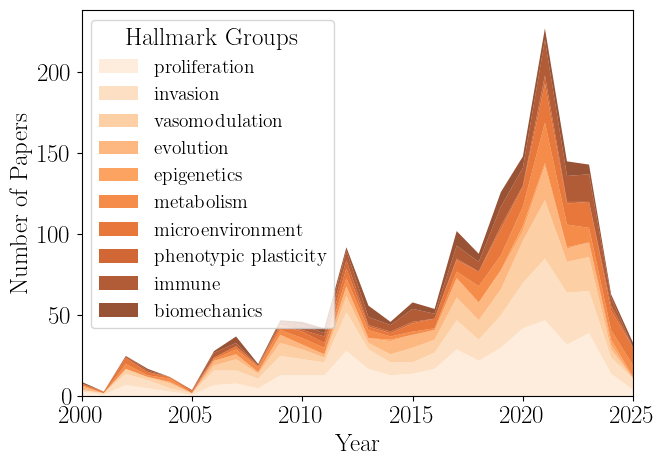

In [11]:
# Extract the Hallmark group columns specified by the user
hallmark_group_columns = [
    'label_group_proliferation', 'label_group_invasion', 'label_group_vasomodulation',
    'label_group_evolution', 'label_group_epigenetics', 'label_group_metabolism', 
    'label_group_microenvironment', 'label_group_phenotypic_plasticity', 
    'label_group_immune', 'label_group_biomechanics'
]
hallmark_group_data = data[['Year'] + hallmark_group_columns]

# Group by year and sum the occurrences of each Hallmark group
hallmark_group_per_year = hallmark_group_data.groupby('Year').sum()/data.shape[0]*100 if percentage else hallmark_group_data.groupby('Year').sum()

# Create shades of orange for each label
colors_orange = plt.cm.Oranges([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# Create a streamgraph (stacked area plot) for Hallmark groups with shades of orange
plt.figure(figsize=(7, 5))
plt.stackplot(
    hallmark_group_per_year.index, 
    hallmark_group_per_year.T, 
    labels=hallmark_group_columns,
    colors=colors_orange,
    alpha=0.8
)
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18
custom_labels_H = ['proliferation', 'invasion', 'vasomodulation',
    'evolution', 'epigenetics', 'metabolism', 
    'microenvironment', 'phenotypic plasticity', 
    'immune', 'biomechanics'
]
plt.legend(custom_labels_H, title = 'Hallmark Groups', loc="upper left", ncol=1, fontsize=14)

# plt.legend(loc='upper left', title="Hallmark Groups")
# plt.title('Hallmark Groups Distribution Over Time (Shades of Orange)')
plt.xlabel('Year')
plt.ylabel('\% of total volume') if percentage else plt.ylabel('Number of Papers')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # Major ticks every 8 years
# plt.xlim(2000,2024)
# plt.tight_layout()
plt.xlim(2000,2025)

# Generate ticks starting from 2000 with a step of 5 years
ticks = [2000, 2005, 2010, 2015, 2020, 2025]

plt.tight_layout()

plt.savefig(f'{output_dir}/Streamgraph_hallmark_groups_percent_vs_time.pdf',dpi=400, bbox_inches='tight') if percentage else plt.savefig(f'{output_dir}/Streamgraph_hallmark_groups_vs_time.pdf',dpi=400, bbox_inches='tight')
plt.show()

### Choose features from original dataset

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

############################ Choose what features will be used to UMAP ###########################
features = [
'label_ODEs', 'label_PDEs', 'label_Agent_Based_Models', 'label_Hybrid_Multiscale', 'label_ML_AI', 
'label_MR_CT', 'label_DTI', 'label_Biopsies_Histopathology', 'label_Liquid_Biopsies',
'label_Omics', 'label_PET', 'label_Multiphoton_Imaging', 'label_Photoacoustics', 'label_in_vitro_mouse',
'label_cell-cycle', 'label_growth_rate', 'label_proliferation', 
'label_chemotaxis-haptotaxis', 'label_invasion', 'label_migration',
'label_angiogenesis', 'label_vasculature', 'label_BBB', 
'label_carcinogenesis', 'label_clonal_evolution', 'label_stem_cells', 'label_tumorigenesis',
'label_epigenomics_epigenetics',
'label_glycolysis', 'label_metabolism',
'label_brain_microenvironment', 'label_tumor_microenvironment', 
'label_phenotypic_plasticity', 
'label_immune',
'label_biomechanical','label_mechanobiology'
]

X = data[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
data_scaled = X_scaled.copy()
data_scaled_for_Umap  = data_scaled.copy()
data_for_Umap  = data[features].copy()


----
### Cluster on UMAP features

In [13]:
###### Manually adjust min_dist, n_components and random_state ##################
###### to create initial UMAP on which clustering will be conducted #############
import umap

reducer = umap.UMAP(n_neighbors=80, min_dist=0.01, n_components=3, random_state=42)
# data_umap = reducer.fit_transform(data_scaled_for_Umap)
data_umap = reducer.fit_transform(data_for_Umap)

data[['UMAP1', 'UMAP2', 'UMAP3']] = data_umap
features = ['UMAP1','UMAP2', 'UMAP3']
X = data[features]
# Χ=data_umap

scaler = StandardScaler ()
X_scaled = scaler.fit_transform(X)
data_scaled = X_scaled. copy()

In [14]:
fig = go.Figure(data=[go.Scatter3d(
    x=data['UMAP1'],  # First principal component
    y=data['UMAP2'],  # Second principal component
    z=data['UMAP3'],  # Third principal component
    mode='markers',
    marker=dict(
        size=5,
        colorscale='Viridis',  # Color scale
        opacity=0.8
    )
)])

# Update the layout of the figure
fig.update_layout(
    title="3D Scatter Plot of the First Three Principal Components",
    scene=dict(
        xaxis=dict(title='UMAP1',showbackground=False),
        yaxis=dict(title='UMAP2',showbackground=False),
        zaxis=dict(title='UMAP3',showbackground=True)
    ),
    width=900,
    height=800
)

fig.show()

## K-means

In [15]:
from sklearn.cluster import KMeans
############# Manually change k to check what number of clusters returns ###########
############# highest silhouette score using K-means ###############################

# Number of clusters
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init ='auto')
Kmeans_clusters = kmeans.fit_predict(data_scaled)

data.loc[:, 'Kmeans_Cluster'] = Kmeans_clusters

# Print the size of each cluster
# print(data['Kmeans_Cluster'].value_counts())

# Explore means of each cluster for each feature
cluster_means = data.groupby('Kmeans_Cluster')[features].mean()

from sklearn.metrics import silhouette_score
# Evaluate clustering quality using silhouette score
sil_score = silhouette_score(X_scaled, Kmeans_clusters)
print(f'Silhouette Score: {sil_score:.3f}')

Silhouette Score: 0.510


## Gaussian Mixture Models (GMM) 

In [16]:
######### Manually change n_components to check what number of clusters returns #####
######### highest silhouette score using GMM ########################################

# Number of clusters
n_components = 4

gmm = GaussianMixture(n_components=n_components, random_state=42)

gmm.fit(X_scaled)
GMM_labels = gmm.predict(X_scaled)

data['GMM_Cluster'] = GMM_labels

from sklearn.metrics import silhouette_score
# Evaluate clustering quality using silhouette score
sil_score = silhouette_score(X_scaled, GMM_labels)
print(f'Silhouette Score: {sil_score:.3f}')


Silhouette Score: 0.487


In [17]:
data['Kmeans_Cluster'] = data['Kmeans_Cluster'] + 1
data['GMM_Cluster'] = data['GMM_Cluster'] + 1

## UMAP on clusters - Uncomment to check

In [18]:
# module.plot_umap_clusters(data_scaled=data_scaled, data_original=data, output_dir=output_dir, n_neighbors=80, min_dist=1,type='Kmeans')

In [19]:
# module.plot_umap_clusters(data_scaled=data_scaled, data_original=data, output_dir=output_dir, n_neighbors=80, min_dist=1, type='GMM')

----
## Feature Importance

In [20]:
#################### Choose what features will be investigated ########################

features = [
'label_ODEs', 'label_PDEs', 'label_Agent_Based_Models', 'label_Hybrid_Multiscale', 'label_ML_AI', 

'label_MR_CT', 'label_DTI', 'label_Biopsies_Histopathology', 'label_Liquid_Biopsies',
'label_Omics', 'label_PET', 'label_Multiphoton_Imaging', 'label_Photoacoustics', 'label_in_vitro_mouse',

'label_cell-cycle', 'label_growth_rate', 'label_proliferation', 
'label_chemotaxis-haptotaxis', 'label_invasion', 'label_migration',
'label_angiogenesis', 'label_vasculature', 'label_BBB', 
'label_carcinogenesis', 'label_clonal_evolution', 'label_stem_cells', 'label_tumorigenesis',
'label_epigenomics_epigenetics',
'label_glycolysis', 'label_metabolism',
'label_brain_microenvironment', 'label_tumor_microenvironment', 
'label_phenotypic_plasticity', 
'label_immune',
'label_biomechanical','label_mechanobiology'
]

X = data[features]

All cluster feature importance plots have been saved to "figures"


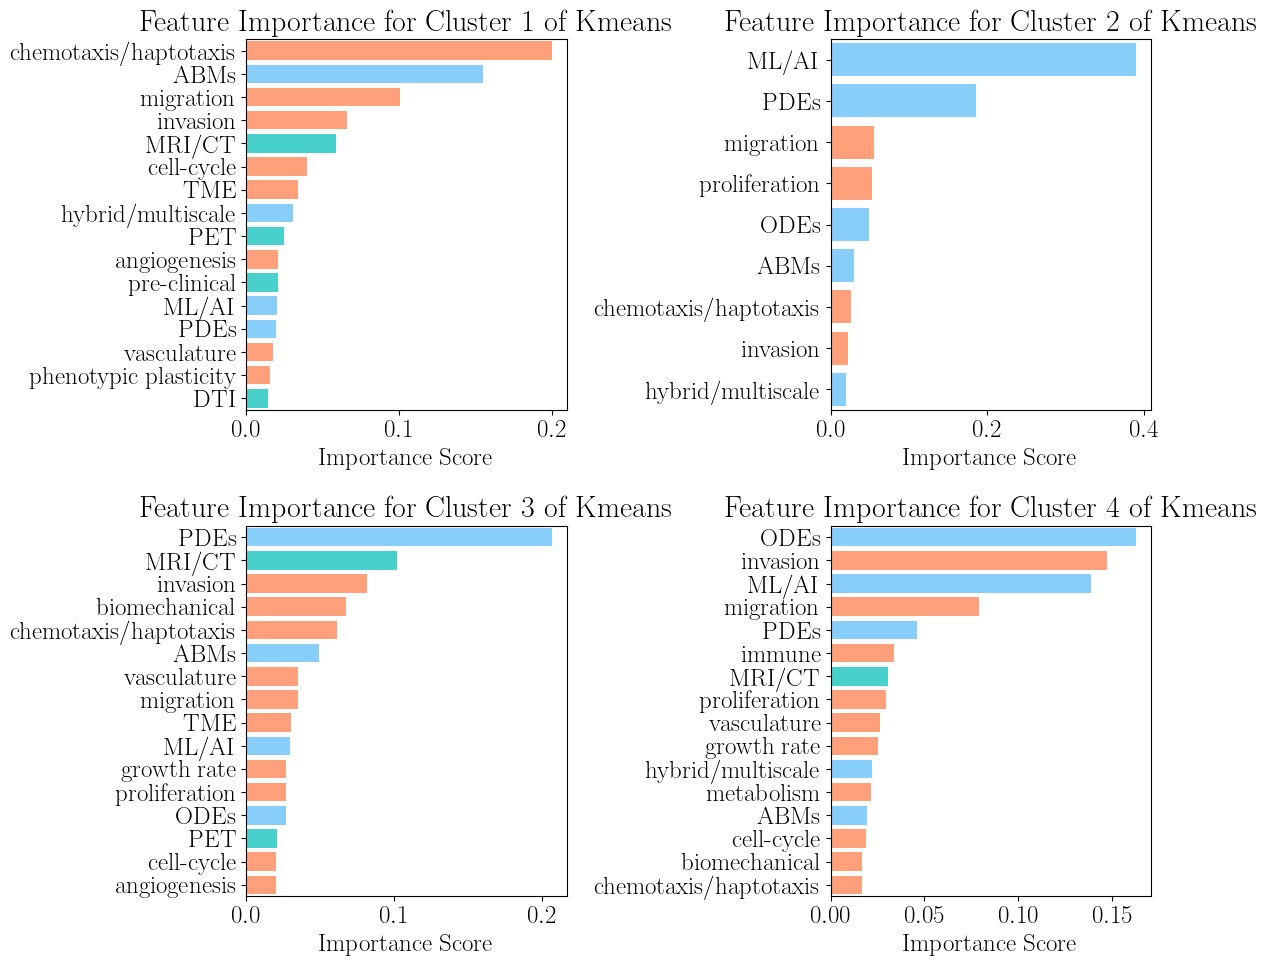

In [21]:
import cancer_dataset_module as module
####### Set manually which method's clusters will be analysed ######
method='Kmeans'
# method='GMM'

y = data[f'{method}_Cluster']
cluster_feature_importances = module.compute_cluster_feature_importances(X, y)

######## Save figures in plots/ - Manually change target_percentage #######
module.save_cluster_feature_importance_with_colors(cluster_feature_importances, method, output_dir=output_dir, target_percentage=0.99, top=20)

######## Print on screen - Manually change target_percentage ##############
module.plot_cluster_feature_importance(cluster_feature_importances, method, columns=2, target_percentage=0.84)

In [22]:
module.plot_umap_clusters(data_scaled=data_scaled, data_original=data, output_dir=output_dir, n_neighbors=80, min_dist=1, type=method)

Plot saved to figures/UMAP_Kmeans_Clusters.html


---
# Cluster summarized information

In [23]:
# Save list of publications per cluster
# Determine which variable to use for the naming/loop
cluster_count = k if method == "Kmeans" else n_components
column_name = f"{method}_Cluster"

# 2. Create the directory
save_path = f"{data_dir}/publication_lists_of_{cluster_count}_{method}_clusters"
os.makedirs(save_path, exist_ok=True)

# 3. Loop and save
for c in range(1, cluster_count + 1):
    # Filter data based on the dynamic column name
    df_c = data[data[column_name] == c]
    
    # Save using dynamic naming
    file_name = f"{cluster_count}_{method}_Cluster_{c}.csv"
    df_c.to_csv(f"{save_path}/{file_name}", index=False)
print(f'The publication lists per cluster were saved in {save_path}')

The publication lists per cluster were saved in datasets/publication_lists_of_4_Kmeans_clusters


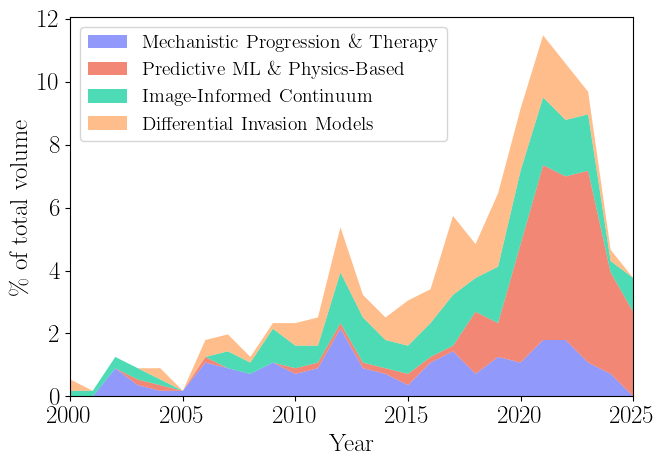

In [24]:
percentage = True

# Increment the cluster numbering by 1
data[f'{method}_Cluster'] = data[f'{method}_Cluster']

# Regenerate the counts with the updated cluster numbers
cluster_counts_per_year_updated = data.groupby(['Year', f'{method}_Cluster']).size().unstack(fill_value=0)/data.shape[0]*100 if percentage else data.groupby(['Year', 'Kmeans_Cluster']).size().unstack(fill_value=0)

# Define the custom colors (matching the image color scheme)
custom_colors = [
    '#636efa', '#ef553b', '#00cc96', '#ffa15a','#ab63fa', 
    '#1bd3f3', '#ff6c96', '#cbeea5', '#fe9eff'
]

# Create the streamgraph with custom colors and cluster numbering starting from 1
plt.figure(figsize=(7, 5))
plt.stackplot(
    cluster_counts_per_year_updated.index, 
    cluster_counts_per_year_updated.T, 
    colors=custom_colors, 
    alpha=0.7
)

# Define cluster descriptions
cluster_descriptions = [
    "Mechanistic Progression \& Therapy",  # Cluster 1
    "Predictive ML \& Physics-Based",  # Cluster 2
    "Image-Informed Continuum",  # Cluster 3
    "Differential Invasion Models",  # Cluster 4
    "Cluster 5",
    "Cluster 6",  # Cluster 6
    "Cluster 7",  # Cluster 7
    "Cluster 8",  # Cluster 8
    "Cluster 9"   # Cluster 9
]

# Generate custom labels by iterating through clusters and their descriptions
# custom_labels = [f"Cluster {i+1}: {desc}" for i, desc in enumerate(cluster_descriptions)]
custom_labels = [f"{desc}" for i, desc in enumerate(cluster_descriptions)]

plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18
custom_labels_H = ['proliferation', 'invasion', 'vasomodulation',
    'evolution', 'epigenetics', 'metabolism', 
    'microenvironment', 'phenotypic plasticity', 
    'immune', 'biomechanics'
]


plt.legend(custom_labels, loc='upper left', ncol=1, fontsize=14)
# plt.legend(custom_labels, loc='upper left', title= f'{method} Cluster', ncol=1, fontsize=14)
# plt.title('Number of Papers per Cluster Over Time')
plt.xlabel('Year')
plt.ylabel('\% of total volume') if percentage else  plt.ylabel('Number of Papers')

# Adding minor ticks for the years
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))  # Major ticks every 5 years
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))  # Minor ticks every year
# ax.tick_params(axis='x', which='minor', length=4)      # Customize the length of the minor ticks
# ax.tick_params(axis='x', which='major', length=6)      # Customize the length of the major ticks
plt.xlim(2000,2025)
plt.tight_layout()

plt.savefig(f'{output_dir}/papers_percent_per_cluster_vs_time.pdf',dpi=400, bbox_inches='tight') if percentage else  plt.savefig(f'{output_dir}/papers_per_cluster_vs_time.pdf',dpi=400, bbox_inches='tight')
plt.show()

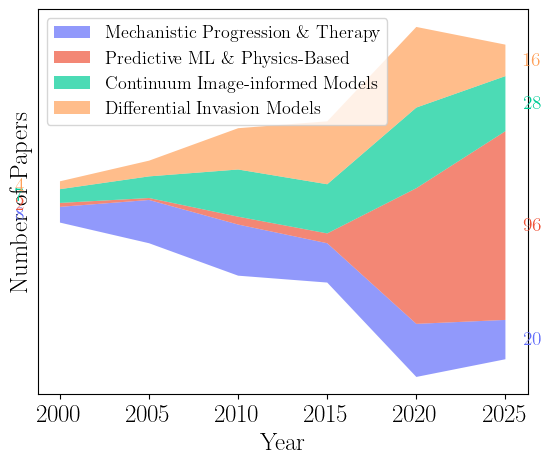

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# A) Basic Parameters
percentage = False

# B) Manually define bins to ensure 2024 is included
bins = [2000, 2005, 2010, 2014, 2018, 2022, 2026]

data['Year_Binned'] = pd.cut(
    data['Year'],
    bins=bins,
    right=False,
    labels=['2000–2004', '2005–2009', '2010–2013', '2014–2017', '2018–2021', '2022–2025']
)

custom_colors = [
    '#636efa', '#ef553b', '#00cc96', '#ffa15a','#ab63fa', 
    '#1bd3f3', '#ff6c96', '#cbeea5', '#fe9eff'
]

# C) Calculate counts for each cluster per window
cluster_counts_per_window = (
    data.groupby(['Year_Binned', f'{method}_Cluster'])
    .size()
    .unstack(fill_value=0)
)

# D) Normalize to percentages if needed
cluster_counts_for_plot = (
    cluster_counts_per_window
    .div(cluster_counts_per_window.sum(axis=1), axis=0) * 100
    if percentage 
    else cluster_counts_per_window
)

# E) Manually define labels
window_labels = [
    "2000", "2005", "2010", "2015", "2020", "2025"
]
cluster_counts_for_plot.index = window_labels

# F) Create streamgraph
plt.figure(figsize=(7, 5))
plt.stackplot(
    cluster_counts_for_plot.index, 
    cluster_counts_for_plot.T, 
    colors=custom_colors, 
    alpha=0.7,
    baseline='sym'  # streamgraph style
)

# G) Cluster descriptions (for legend)
cluster_descriptions = [
    "Mechanistic Progression \& Therapy",  # Cluster 1
    "Predictive ML \& Physics-Based",      # Cluster 2
    "Continuum Image-informed Models",     # Cluster 3
    "Differential Invasion Models",        # Cluster 4
    "Cluster 5",                           # Cluster 5
    "Cluster 6",                           # Cluster 6
    "Cluster 7",                           # Cluster 7
    "Cluster 8",                           # Cluster 8
    "Cluster 9"                            # Cluster 9
]
custom_labels = [desc for desc in cluster_descriptions]

# -- Configure plotting style --
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

# H) Legend and axis labels
# H) Legend and axis labels
plt.legend(
    custom_labels, 
    loc='upper left', 
    ncol=1, 
    fontsize=13, 
    frameon=True  # Disable the legend box
)
# plt.legend(custom_labels, loc='upper left', ncol=1, fontsize=14)
plt.xlabel('Year')
plt.ylabel('\% of papers' if percentage else 'Number of Papers')

# Keep the x-axis ticks
# plt.xticks(rotation=45)

# Remove y-axis ticks
plt.yticks([])
ax = plt.gca()

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(True)

# **Increase left margin** to give more space to labels
# You can adjust this value until the annotations look good
plt.subplots_adjust(left=0.2)

# I) Function to annotate the first or last bin
def annotate_bin(bin_counts, bin_index, x_offset, h_align, color_list):
    """
    Annotate the symmetrical stack for the bin at 'bin_index'
    with absolute cluster counts in 'bin_counts'.

    Parameters:
    -----------
    bin_counts : array-like
        Absolute counts for each cluster in that bin (in ascending cluster order).
    bin_index : float
        x-position of the bin (integer index).
    x_offset : float
        Horizontal offset to shift the text (negative for left, positive for right).
    h_align : str
        Horizontal alignment ('left' or 'right').
    color_list : list
        Colors for each cluster, same ordering as bin_counts.
    """
    total_in_bin = bin_counts.sum()
    current_lower = -total_in_bin / 2.0  # symmetrical baseline
    min_separation = 0.4                # minimal vertical gap to avoid label overlap
    last_label_y = None

    for i, count in enumerate(bin_counts):
        current_upper = current_lower + count
        y_mid = (current_lower + current_upper) / 2.0

        # If needed, nudge upward to avoid overlap
        if last_label_y is not None and (y_mid - last_label_y) < min_separation:
            y_mid = last_label_y + min_separation

        # Plot annotation, matching cluster color
        plt.text(
            bin_index + x_offset,
            y_mid,
            str(int(count)),
            ha=h_align,
            va='center',
            fontsize=14,
            color=color_list[i]
        )

        last_label_y = y_mid
        current_lower = current_upper

# J) If not percentage, annotate first and last bin in cluster color
if not percentage:
    # 1) First bin: x = 0
    first_bin_counts = cluster_counts_per_window.iloc[0, :].values
    # Increase the negative offset to -0.3 or -0.4 for more space
    annotate_bin(
        bin_counts=first_bin_counts,
        bin_index=0,        
        x_offset=-0.4,      # shift left more (was -0.2)
        h_align='right',
        color_list=custom_colors
    )

    # 2) Last bin: x = len(window_labels) - 1
    last_bin_counts = cluster_counts_per_window.iloc[-1, :].values
    last_bin_index = len(window_labels) - 1
    annotate_bin(
        bin_counts=last_bin_counts,
        bin_index=last_bin_index, 
        x_offset=0.2,       
        h_align='left',
        color_list=custom_colors
    )

# K) Save and show
if percentage:
    plt.savefig(
        f'{output_dir}/papers_percent_per_cluster_vs_4year_windows_streamgraph.pdf',
        dpi=400,
        bbox_inches='tight'
    )
else:
    plt.savefig(
        f'{output_dir}/papers_per_cluster_vs_4year_windows_streamgraph.pdf', 
        dpi=400,
        bbox_inches='tight'
    )
plt.show()

In [26]:
data.to_csv(f'{data_dir}/Main_Dataset_clustered.csv')

----
# Cluster projection on MM-DT-HlM based on multiclass classification

In [27]:
dataset = data.copy()

In [28]:
# Define the three groups of features
math_methods = ['label_ODEs', 'label_PDEs', 'label_Agent_Based_Models', 'label_Hybrid_Multiscale', 'label_ML_AI']
data_technologies = ['label_MR_CT', 'label_DTI', 'label_Biopsies_Histopathology', 'label_Liquid_Biopsies', 'label_Omics', 
                     'label_PET', 'label_Multiphoton_Imaging', 'label_Photoacoustics', 'label_in_vitro_mouse']
hallmarks = ['label_cell-cycle', 'label_growth_rate', 'label_proliferation', 'label_chemotaxis-haptotaxis', 'label_invasion', 
             'label_migration', 'label_angiogenesis', 'label_vasculature', 'label_BBB', 'label_carcinogenesis', 
             'label_clonal_evolution', 'label_stem_cells', 'label_tumorigenesis', 'label_epigenomics_epigenetics',
             'label_glycolysis', 'label_metabolism', 'label_brain_microenvironment', 'label_tumor_microenvironment',
             'label_phenotypic_plasticity', 'label_immune', 'label_biomechanical', 'label_mechanobiology']

rest = ['Year'
        ,'label_Mathematical_Methods', 'label_Data_Technologies', 'label_Hallmarks'
       ]

In [29]:
# Step 1: Classify Mathematical Methods
features_math = data_technologies + hallmarks + rest  # Use Data Technologies and Hallmarks as features
math_probs = module.classify_group(dataset,features_math, math_methods, 'math')
# math_probs = classify_group0(features_math, math_methods, 'Mathematical Methods')

# Step 2: Classify Data Technologies
features_data_tech = math_methods + hallmarks + rest  # Use Mathematical Methods and Hallmarks as features
data_tech_probs = module.classify_group(dataset,features_data_tech, data_technologies, 'data_tech')
# data_tech_probs = classify_group0(features_data_tech, data_technologies, 'Data Technologies')

# Step 3: Classify Hallmarks
features_hallmarks = math_methods + data_technologies + rest  # Use Mathematical Methods and Data Technologies as features
hallmarks_probs = module.classify_group(dataset,features_hallmarks, hallmarks, 'hallmarks')
# hallmarks_probs = classify_group0(features_hallmarks, hallmarks, 'Hallmarks')

probabilities_df = pd.concat([math_probs, data_tech_probs, hallmarks_probs], axis=1)

# Add the probabilities to the original dataset
final_dataset= pd.concat([dataset, probabilities_df], axis=1)

In [30]:
features_math = data_technologies + hallmarks + rest  # Use Data Technologies and Hallmarks as features
math_probs = module.classify_group_all(dataset, features_math, math_methods, 'math')
math_probs_df = pd.DataFrame(math_probs).T.mean(axis=0)/pd.DataFrame(math_probs).T.mean(axis=0).sum()

features_data_tech = math_methods + hallmarks + rest  # Use Mathematical Methods and Hallmarks as features
data_tech_probs = module.classify_group_all(dataset, features_data_tech, data_technologies, 'data_tech')
data_tech_probs_df = pd.DataFrame(data_tech_probs).T.mean(axis=0)/pd.DataFrame(data_tech_probs).T.mean(axis=0).sum()

features_hallmarks = math_methods + data_technologies + rest  # Use Mathematical Methods and Data Technologies as features
hallmarks_probs = module.classify_group_all(dataset, features_hallmarks, hallmarks, 'hallmarks')
hallmarks_probs_df = pd.DataFrame(hallmarks_probs).T.mean(axis=0)/pd.DataFrame(hallmarks_probs).T.mean(axis=0).sum()


In [31]:
# Multiply the values in each set of columns by the corresponding probabilities dataframe
dataset['MM'] = dataset[math_methods].multiply(math_probs_df.values, axis=1).sum(axis=1)
dataset['DT'] = dataset[data_technologies].multiply(data_tech_probs_df.values, axis=1).sum(axis=1)
dataset['Hm'] = dataset[hallmarks].multiply(hallmarks_probs_df.values, axis=1).sum(axis=1)

In [32]:
# dataset.head(1)

In [33]:
# Group by the '{method}_Cluster' and calculate the mean for 'MM', 'DT', and 'Hm'
cluster_centers = dataset.groupby(f'{method}_Cluster')[['MM', 'DT', 'Hm']].mean()

In [34]:
## Uncomment for interactive clusters/centers

# module.plot_clustered_probabilities_with_centers(
#     data=dataset, prob_cols=['MM', 'DT', 'Hm'], 
#     output_dir=output_dir, cluster_col=f"{method}_Cluster"
# )

In [35]:
dataset.to_csv(f'{data_dir}/Main_Dataset_clustered.csv', index=True)

---
# Distribution of Cluster on each of the 'MM', 'DT' and 'Hm' axis

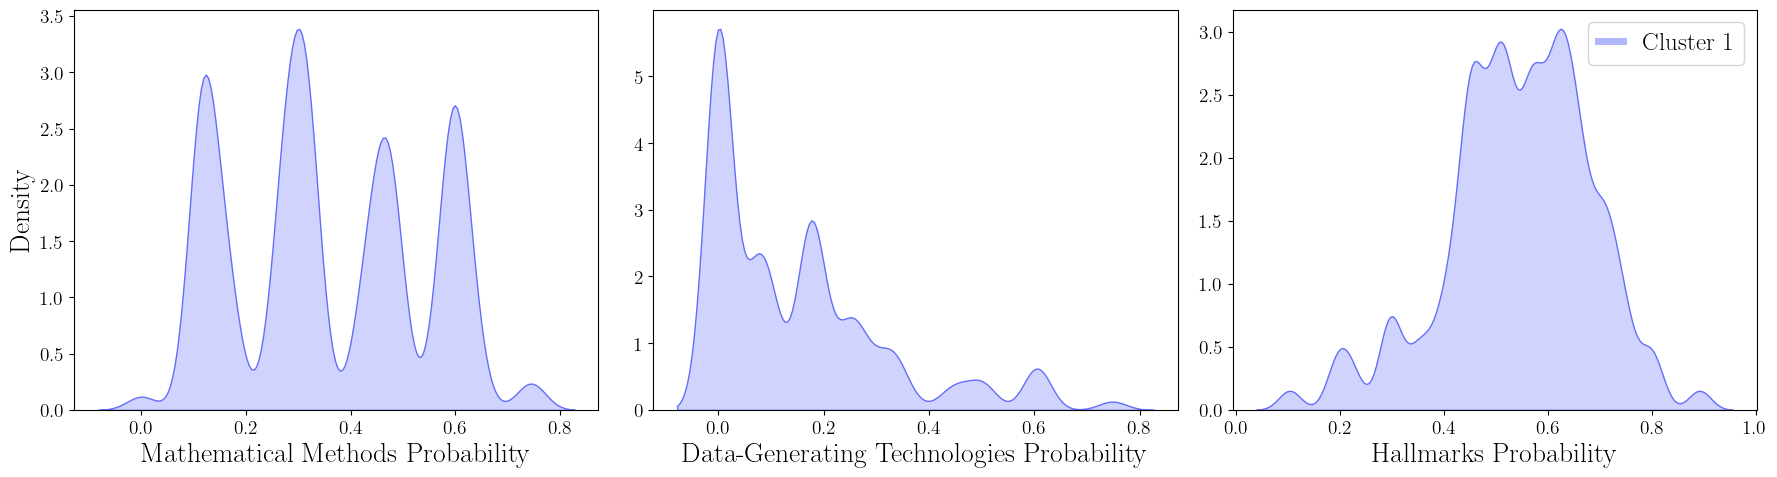

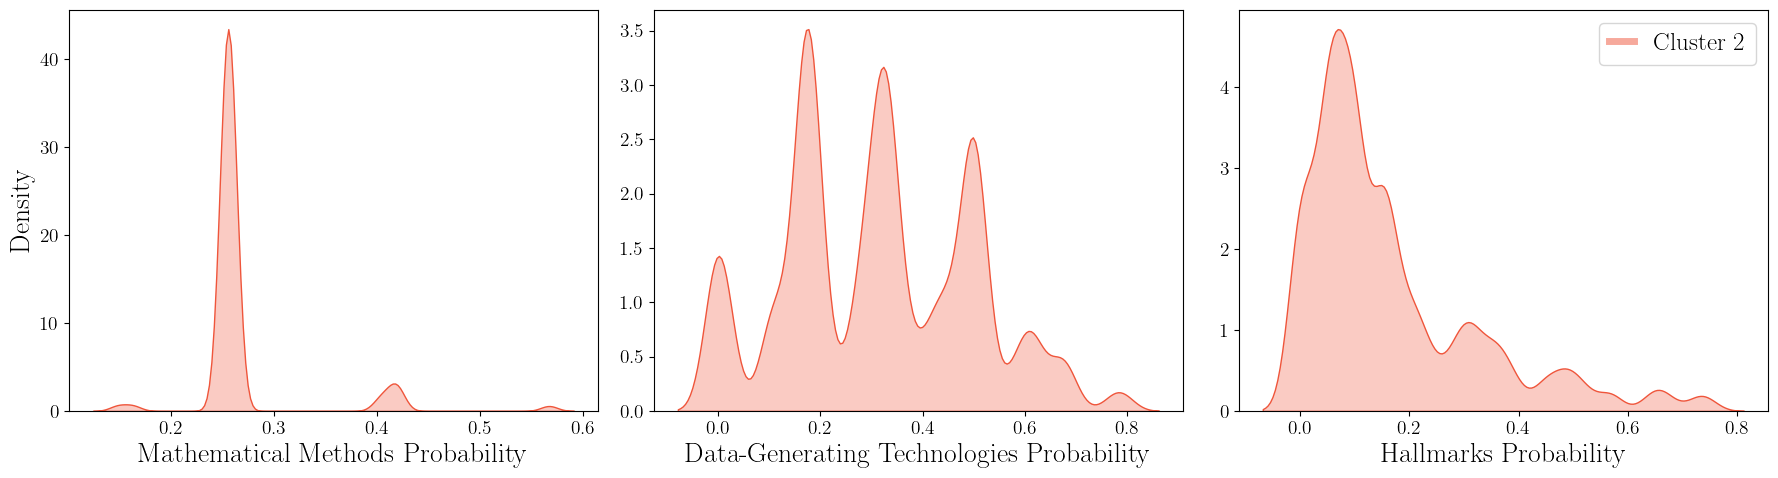

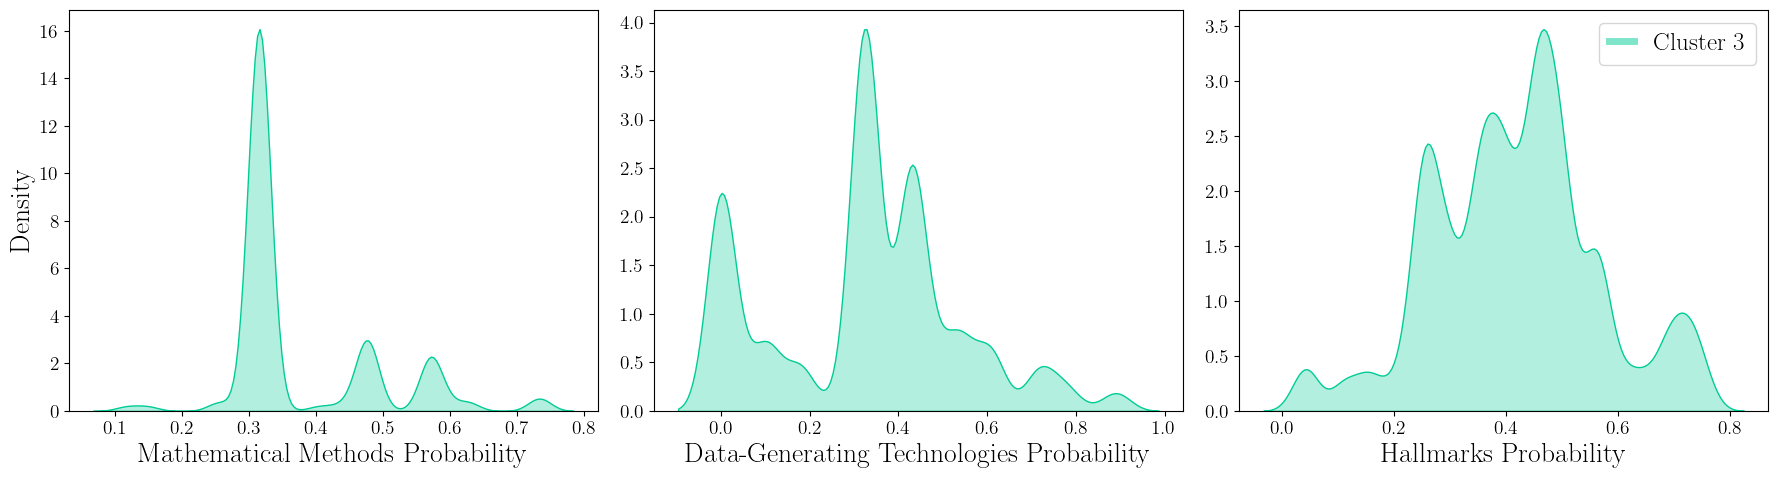

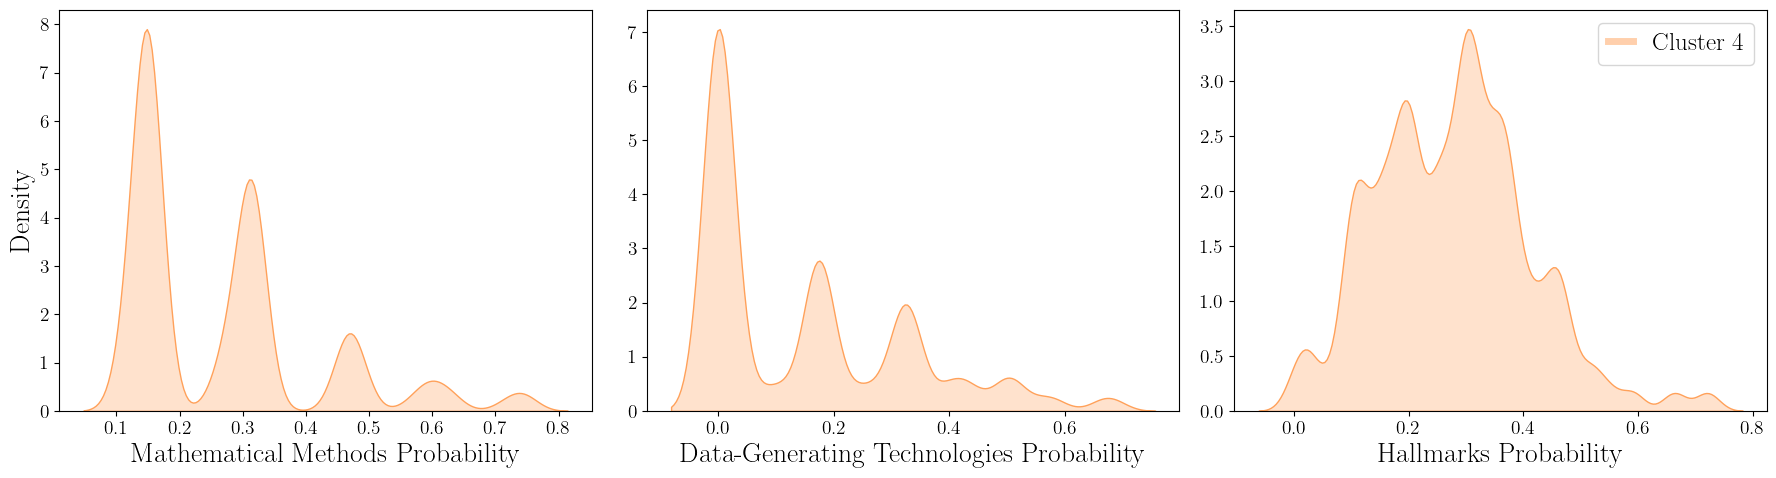

In [36]:
for i in range(1, cluster_count + 1):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    module.plot_cluster_distribution_sns(dataset, method, i, axes)
    plt.tight_layout()
    plt.show()

----
# Evolution of Cluster's Center in yearly windows with distributions planes

In [46]:
import cancer_dataset_module as module

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
autoreload 2

In [57]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap, to_rgba, to_hex
import pandas as pd

custom_colors = [
    '#1bd3f3', '#636efa', '#ef553b', '#00cc96', '#ffa15a','#ab63fa', 
    '#1bd3f3', '#ff6c96', '#cbeea5', '#fe9eff'
    ]
# year_ranges = [(2000, 2003), (2004, 2008), (2009, 2012), (2013, 2016), (2017, 2020), (2021, 2024)]
year_ranges = [(2000, 2004), (2005, 2009), (2010, 2013), (2014, 2017), (2018, 2021), (2022, 2025)]

# Function to assign year range
def assign_year_range(year):
    for start, end in year_ranges:
        if start <= year <= end:
            return f"{start}-{end}"
    return None

# Assign each row in the dataset to its respective year range
data['Year_Range'] = data['Year'].apply(assign_year_range)
 
# Calculate cluster centers by year range
def calculate_cluster_centers_by_range(data, method):
    cluster_range_centers = (
        data.groupby([f'{method}_Cluster', 'Year_Range'])
        .agg({'MM': 'mean', 'DT': 'mean', 'Hm': 'mean', f'{method}_Cluster': 'size'})
        .rename(columns={f'{method}_Cluster': 'Count'})
        .reset_index()
    )
    return cluster_range_centers

# Function to create a gradient color map for a given base color
def create_gradient_colors(base_color, n_colors):
    rgba_color = to_rgba(base_color)
    color_list = [
        (rgba_color[0], rgba_color[1], rgba_color[2], alpha)
        for alpha in np.linspace(0.1, 1, n_colors)
    ]
    return color_list

def create_colormap(color):
    return LinearSegmentedColormap.from_list('custom_cmap', ['white', color], N=100)

# Function to plot the 2D distribution of a specific cluster for two axes
def plot_2d_kde(data, axis1, axis2, grid_size=100):
    kde = gaussian_kde([data[axis1], data[axis2]])
    x_min, x_max = data[axis1].min(), data[axis1].max()
    y_min, y_max = data[axis2].min(), data[axis2].max()
    x_grid = np.linspace(x_min, x_max, grid_size)
    y_grid = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde([X.ravel(), Y.ravel()]).reshape(X.shape)
    Z[Z < Z.max() * 0.01] = np.nan  # Optional threshold to remove low-density areas
    threshold =0
    # Apply threshold: set Z values below threshold to NaN (or 0 if NaN is unsuitable)
    # if threshold is not None:
    #     Z[Z < threshold] = np.nan  # NaN will create empty spaces in plotting

    return x_min, y_min, x_max, y_max, X, Y, Z

def darken_color(color, amount=0.3):
    rgba_color = to_rgba(color)
    darkened_color = (rgba_color[0] * (1 - amount), rgba_color[1] * (1 - amount), rgba_color[2] * (1 - amount), rgba_color[3])
    return to_hex(darkened_color)


# Adjusted function to plot with consistent dimensions for each parameter
def plot_3d_with_range_centers(data, method, cluster_num, cluster_centers, range_centers):
    cluster_data = data[data[f'{method}_Cluster'] == cluster_num]
    # Pre-calculated main center
    center_mm = cluster_centers.loc[cluster_num, 'MM']
    center_dt = cluster_centers.loc[cluster_num, 'DT']
    center_hm = cluster_centers.loc[cluster_num, 'Hm']
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Color for this cluster
    cluster_color = custom_colors[cluster_num % len(custom_colors)]
    colormap = create_colormap(cluster_color)

    # Plot range centers for this cluster
    range_cluster_data = range_centers[range_centers[f'{method}_Cluster'] == cluster_num]
    gradient_colors = create_gradient_colors(cluster_color, len(year_ranges))

    # MM-DT plane (aligned with the z-axis)
    x_min_mm_dt, y_min_mm_dt, x_max_mm_dt, y_max_mm_dt, X_mm_dt, Y_mm_dt, Z_mm_dt = plot_2d_kde(cluster_data, 'MM', 'DT')    
    # MM-Hm plane (aligned with the y-axis)
    x_min_mm_hm, y_min_mm_hm, x_max_mm_hm, y_max_mm_hm, X_mm_hm, Y_mm_hm, Z_mm_hm = plot_2d_kde(cluster_data, 'MM', 'Hm')
    # DT-Hm plane (aligned with the x-axis)
    x_min_dt_hm, y_min_dt_hm, x_max_dt_hm, y_max_dt_hm, X_dt_hm, Y_dt_hm, Z_dt_hm = plot_2d_kde(cluster_data, 'DT', 'Hm')

    invert = True 
    xoffset = min(x_max_mm_dt, x_max_mm_hm) if invert else 0 

    
    # Plot 2D density contours on each plane
    ax.contourf(X_mm_dt, Y_mm_dt, Z_mm_dt, zdir='z', offset=min(y_min_mm_hm, y_min_dt_hm), cmap=colormap, alpha=0.5, zorder=1)
    ax.contourf(X_mm_hm, Z_mm_hm, Y_mm_hm, zdir='y', offset=min(y_min_mm_dt, y_min_dt_hm), cmap=colormap, alpha=0.5, zorder=2)
    ax.contourf(Z_dt_hm, X_dt_hm, Y_dt_hm, zdir='x', offset=xoffset if invert else min(x_min_mm_dt, x_min_mm_hm), cmap=colormap, alpha=0.5, zorder=3)

    prev_mm, prev_dt, prev_hm = None, None, None
    # Plot the range cluster centers in each plane and connect the points on each plane with lines
    for i, (year_range, color) in enumerate(zip(year_ranges, gradient_colors)):
        range_data = range_cluster_data[range_cluster_data['Year_Range'] == f"{year_range[0]}-{year_range[1]}"]

        if not range_data.empty:
            mm, dt, hm = range_data['MM'].values[0], range_data['DT'].values[0], range_data['Hm'].values[0]
            
            # Plot the main point for each year range
            ax.scatter(mm, dt, hm, zorder=3 + i, s=range_data['Count'].values[0] * 10, #marker='D',
                       color=color, edgecolor='black', alpha=0.7, label=f"{year_range[0]}-{year_range[1]}")# (Count: {range_data['Count'].values[0]})")
            
            # Plot projections on each plane
            ax.scatter(mm, dt, min(y_min_mm_hm, y_min_dt_hm), s=(i + 1) * 5, color=darken_color(color, amount=0.5), alpha=0.5, edgecolor='black')
            ax.scatter(mm, min(y_min_mm_dt, y_min_dt_hm), hm, s=(i + 1) * 5, color=darken_color(color, amount=0.5), alpha=0.5, edgecolor='black')
            ax.scatter(xoffset if invert else min(x_min_mm_dt, x_min_mm_hm), dt, hm, s=(i + 1) * 5, color=darken_color(color, amount=0.5), alpha=0.5, edgecolor='black')
    
            # Draw connecting lines if there is a previous point
            if prev_mm is not None:
                ax.plot([prev_mm, mm], [prev_dt, dt],       zs=[min(y_min_mm_hm, y_min_dt_hm)] * 2, linewidth = 1, color=darken_color(color, amount=0.8), linestyle='--', alpha=0.5)
                ax.plot([prev_mm, mm], zs=[prev_hm, hm], ys=[min(y_min_mm_dt, y_min_dt_hm)] * 2,    linewidth = 1, color=darken_color(color, amount=0.8), linestyle='--', alpha=0.5)
                ax.plot(xs=[xoffset if invert else min(x_min_mm_dt, x_min_mm_hm)] * 2, ys=[prev_dt, dt], zs=[prev_hm, hm], linewidth = 1, color=darken_color(color, amount=0.8), linestyle='--', alpha=0.5)
                if invert: ax.invert_xaxis()  # Invert the MM axis

            # Update previous coordinates to current values for the next iteration
            prev_mm, prev_dt, prev_hm = mm, dt, hm

    # Plot the main cluster center
    ax.scatter(center_mm, center_dt, center_hm, zorder=10, #marker='D',
               color='black', s=int(cluster_data.shape[1]) * 1, edgecolor='black', alpha=1, linewidth=1)

    # Set labels and limits
    ax.set_xlabel('Mathematical Methods', labelpad=8)
    ax.set_ylabel('Data-Generating Technologies', labelpad=8)
    ax.set_zlabel('Hallmarks', labelpad=6)

    ax.set_xlim([min(0.1, x_min_mm_dt), x_max_mm_dt])
    ax.set_ylim([min(0.1, x_min_dt_hm), x_max_dt_hm])
    ax.set_zlim([min(0.3, y_min_mm_hm), y_max_mm_hm])
    if invert: ax.invert_xaxis()  # Invert the MM axis

    # Remove axis panes and optionally, gridlines
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    # View and legend
    ax.view_init(elev=20, azim=45)
    # ax.legend(loc='upper left', framealpha=1, ncol=1, bbox_to_anchor=(0.71, 0.93), fontsize=16)
    # ax.legend(loc='upper left', framealpha=1, ncol=1, bbox_to_anchor=(0.05, 0.93), fontsize=16)
    # ax.legend(loc='upper right', framealpha=1, ncol=1, bbox_to_anchor=(0.055, 0.60), fontsize=15)
    ax.legend(loc='upper left', framealpha=1, ncol=1, bbox_to_anchor=(0.71, 0.85), fontsize=15)

    plt.tight_layout()
    fig.subplots_adjust(left=0.3, right=1.0, top=1, bottom=0.0)

    plt.savefig(f'{output_dir}/3D_Probability_Density_of_Cluster_{cluster_num}_with_trajectories.pdf', dpi=400)#, bbox_inches='tight')
    plt.show()

    # Save the plot as a standalone HTML file
    # filename = f'{output_dir}/3D_Probability_Density_of_Cluster_{cluster_num}_with_trajectories.html'
    # filepath = f'{output_dir}'
    # pio.write_html(fig, file=filepath, full_html=True)
    # print(f'Plot saved to {filepath}')

dataset['Year_Range'] = dataset['Year'].apply(assign_year_range)

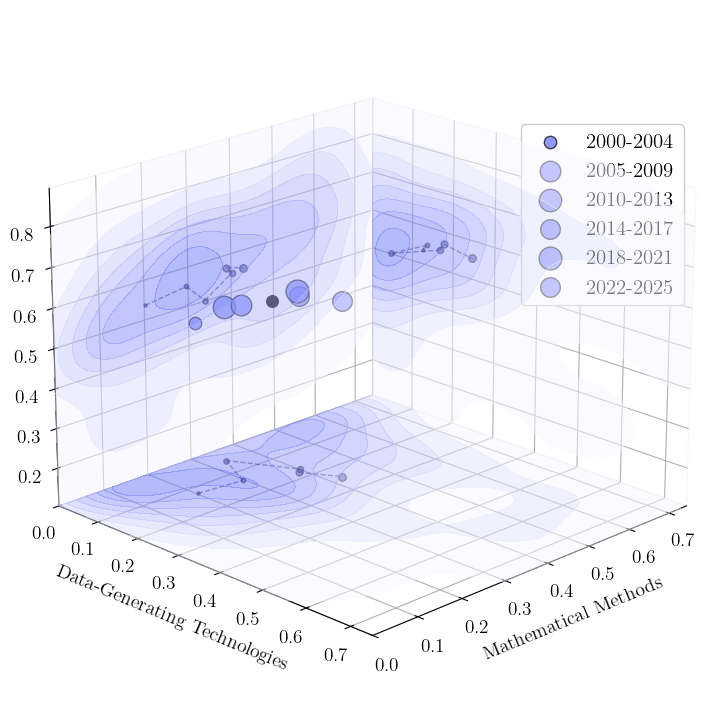

In [61]:
# Change manually for each cluster
clst = 1
plot_3d_with_range_centers(dataset, method, clst, cluster_centers, calculate_cluster_centers_by_range(dataset, method))

----
# Evolution of Cluster's Center in yearly windows with distributions planes - Full dataset - Projections

In [62]:
# Multiply the values in each set of columns by the corresponding probabilities dataframe
dataset['MM'] = dataset[math_methods].multiply(math_probs_df.values, axis=1).sum(axis=1)
dataset['DT'] = dataset[data_technologies].multiply(data_tech_probs_df.values, axis=1).sum(axis=1)
dataset['Hm'] = dataset[hallmarks].multiply(hallmarks_probs_df.values, axis=1).sum(axis=1)

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap, to_rgba, to_hex
import pandas as pd

# Define time ranges
year_ranges = [(2000, 2004), (2005, 2009), (2010, 2013), (2014, 2017), (2018, 2021), (2022, 2025)]


# Assign custom colors
custom_colors = [
    '#1bd3f3', '#636efa', '#ef553b', '#00cc96', '#ffa15a','#ab63fa', 
    '#1bd3f3', '#ff6c96', '#cbeea5', '#fe9eff'
]
class Arrow3D(FancyArrowPatch):
    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# Adding the arrow3D method to the Axes3D class
def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)

setattr(Axes3D, 'arrow3D', _arrow3D)

# Function to assign year range
def assign_year_range(year):
    for start, end in year_ranges:
        if start <= year <= end:
            return f"{start}-{end}"
    return None

# Assign each row in the dataset to its respective year range
dataset['Year_Range'] = dataset['Year'].apply(assign_year_range)

# Calculate overall centers by year range (ignoring clusters)
def calculate_overall_centers_by_range(data):
    overall_centers = (
        data.groupby('Year_Range')
        .agg({'MM': 'mean', 'DT': 'mean', 'Hm': 'mean', 'Year_Range': 'size'})
        .rename(columns={'Year_Range': 'Count'})
        .reset_index()
    )
    return overall_centers

# Function to calculate KDE for each 2D plane
def calculate_2d_kde(data, axis1, axis2, grid_size=100):
    kde = gaussian_kde([data[axis1], data[axis2]])
    x_min, x_max = data[axis1].min(), data[axis1].max()
    y_min, y_max = data[axis2].min(), data[axis2].max()
    x_grid = np.linspace(x_min, x_max, grid_size)
    y_grid = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde([X.ravel(), Y.ravel()]).reshape(X.shape)
    Z[Z < Z.max() * 0.1] = np.nan  # Optional threshold to remove low-density areas
    return x_min, x_max, y_min, y_max, X, Y, Z

# Darken color for lines
def darken_color(color, amount=0.3):
    rgba_color = to_rgba(color)
    darkened_color = (rgba_color[0] * (1 - amount), rgba_color[1] * (1 - amount), rgba_color[2] * (1 - amount), rgba_color[3])
    return to_hex(darkened_color)

# Plotting function with contour plots on each plane
def plot_overall_centers_with_projections(data, overall_centers):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Calculate KDEs for each plane
    x_min_mm_dt, x_max_mm_dt, y_min_mm_dt, y_max_mm_dt, X_mm_dt, Y_mm_dt, Z_mm_dt = calculate_2d_kde(data, 'MM', 'DT')
    x_min_mm_hm, x_max_mm_hm, y_min_mm_hm, y_max_mm_hm, X_mm_hm, Y_mm_hm, Z_mm_hm = calculate_2d_kde(data, 'MM', 'Hm')
    x_min_dt_hm, x_max_dt_hm, y_min_dt_hm, y_max_dt_hm, X_dt_hm, Y_dt_hm, Z_dt_hm = calculate_2d_kde(data, 'DT', 'Hm')

    invert = True 
    # xoffset = min(x_max_mm_dt, x_max_mm_hm) if invert else 0 
    xoffset = min(0.9, x_max_mm_dt, x_max_mm_hm) if invert else 0 
    xoffset = 1 if invert else 0 

    # Plot contour planes
    ax.contourf(X_mm_dt, Y_mm_dt, Z_mm_dt, zdir='z', offset=y_min_mm_hm, cmap='Oranges', alpha=0.4)
    ax.contourf(X_mm_hm, Z_mm_hm, Y_mm_hm, zdir='y', offset=y_min_mm_dt, cmap='Greens', alpha=0.4)
    ax.contourf(Z_dt_hm, X_dt_hm, Y_dt_hm, zdir='x', offset=xoffset, cmap='Blues', alpha=0.4)

    # Plot range centers and projections
    prev_mm, prev_dt, prev_hm = None, None, None
    for i, year_range in enumerate(year_ranges):
        range_label = f"{year_range[0]}-{year_range[1]}"
        range_data = overall_centers[overall_centers['Year_Range'] == range_label]

        if not range_data.empty:
            mm, dt, hm = range_data['MM'].values[0], range_data['DT'].values[0], range_data['Hm'].values[0]
            color = custom_colors[i % len(custom_colors)]
            size = range_data['Count'].values[0] * 5

            # Main center point for the year range
            ax.scatter(mm, dt, hm, s=size, color='black', edgecolor='black', alpha=0.7, label=f"{range_label}")

            # Projection points on each plane
            ax.scatter(mm, dt, y_min_mm_hm, s=(i + 1) * 20, color=darken_color('orange'), alpha=0.5, edgecolor='black')
            ax.scatter(mm, y_min_mm_dt, hm, s=(i + 1) * 20, color=darken_color('green'), alpha=0.5, edgecolor='black')
            ax.scatter(xoffset, dt, hm, s=(i + 1) * 20, color=darken_color('blue'), alpha=0.5, edgecolor='black')

            # Connect previous center with current one if there was a previous point
            if prev_mm is not None:
                ax.plot([prev_mm, mm], [prev_dt, dt], zs=[y_min_mm_hm]*2, color=darken_color('orange'), linestyle='--', alpha=0.5)
                ax.plot([prev_mm, mm], zs=[prev_hm, hm], ys=[y_min_mm_dt]*2, color=darken_color('green'), linestyle='--', alpha=0.5)
                ax.plot(xs=[xoffset]*2, ys=[prev_dt, dt], zs=[prev_hm, hm], color=darken_color('blue'), linestyle='--', alpha=0.5)

            # Update previous point
            prev_mm, prev_dt, prev_hm = mm, dt, hm

    last_two = overall_centers.iloc[-2:]
    count_diff = last_two['Count'].values[1] - last_two['Count'].values[0]
    mm_diff = last_two['MM'].values[1] - last_two['MM'].values[0]
    dt_diff = last_two['DT'].values[1] - last_two['DT'].values[0]
    hm_diff = last_two['Hm'].values[1] - last_two['Hm'].values[0]
    # Define a scaling factor to control the vector length
    scaling_factor = 0.1  # Adjust this value as needed to decrease the scale

    # Calculate the vector and scale it down
    p_vector   = scaling_factor * np.abs(count_diff) * np.array([mm_diff, dt_diff, hm_diff])
    p_vector_1 = scaling_factor * np.abs(count_diff) *np.array([0, dt_diff, hm_diff])
    p_vector_2 = scaling_factor * np.abs(count_diff) *np.array([mm_diff, 0, hm_diff]) 
    p_vector_3 = scaling_factor * np.abs(count_diff) *np.array([mm_diff, dt_diff, 0])

    # Plot the vector starting at the last center
    last_mm, last_dt, last_hm = last_two['MM'].values[1], last_two['DT'].values[1], last_two['Hm'].values[1]

        # Add the 3D arrow
    ax.arrow3D(last_mm, last_dt, last_hm, p_vector[0], p_vector[1], p_vector[2], mutation_scale=20, arrowstyle="-|>", color='black', linestyle='solid')
    ax.arrow3D(xoffset, last_dt, last_hm,          0 , p_vector[1], p_vector[2], mutation_scale=20, arrowstyle="-|>", color='blue', linestyle='solid')
    ax.arrow3D(last_mm,       0, last_hm, p_vector[0],          0 , p_vector[2], mutation_scale=20, arrowstyle="-|>", color='darkgreen', linestyle='solid')
    ax.arrow3D(last_mm, last_dt,       0, p_vector[0], p_vector[1],          0 , mutation_scale=20, arrowstyle="-|>", color='brown', linestyle='solid')

    # Set labels and axis limits
    ax.set_xlabel('Mathematical Methods', labelpad=8)
    ax.set_ylabel('Data-Generating Technologies', labelpad=8)
    ax.set_zlabel('Hallmarks', labelpad=6)
    ax.set_xlim([x_min_mm_dt, xoffset])
    ax.set_ylim([y_min_mm_dt, xoffset])
    ax.set_zlim([y_min_mm_hm, xoffset])
    if invert: ax.invert_xaxis()  # Invert the MM axis

    # ax.set_xlim([x_min_mm_dt, 3])
    # ax.set_ylim([y_min_mm_dt, 4])
    # ax.set_zlim([y_min_mm_hm, 12])

    # Remove background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    # Legend and view setup
    # ax.view_init(elev=30, azim=45)
    ax.view_init(elev=20, azim=45)
    ax.legend(loc='upper left', framealpha=1, ncol=1, bbox_to_anchor=(0.71, 0.76), fontsize=15)
    # ax.legend(loc='upper left', framealpha=1, ncol=1, bbox_to_anchor=(0.055, 0.60), fontsize=15)

    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/3D_Probability_Density_of_full_dataset_with_trajectories.pdf', dpi=400)#, bbox_inches='tight')

    plt.show()

In [65]:
# Calculate overall centers and plot
overall_centers = calculate_overall_centers_by_range(dataset)

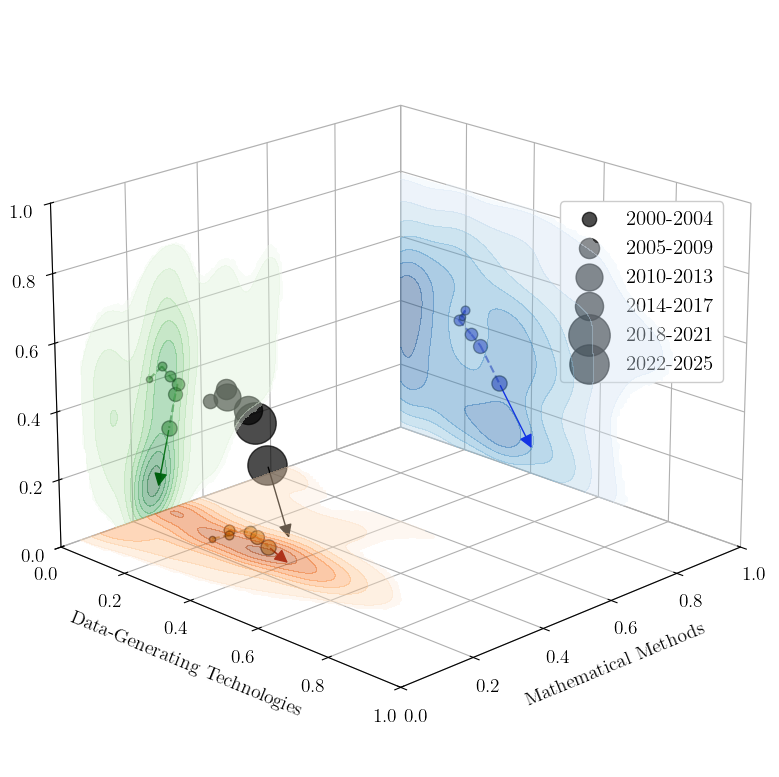

In [66]:
plot_overall_centers_with_projections(dataset, overall_centers)

---
## Add unity weight in non-zero weights 
### (same results as above, but streched better)

In [67]:
# # Sum across each group of columns
# dataset['MM'] = dataset[math_methods].sum(axis=1)
# dataset['DT'] = dataset[data_technologies].sum(axis=1)
# dataset['Hm'] = dataset[hallmarks].sum(axis=1)

# Scale each column to its maximum value
dataset['MM'] = dataset['MM'] / dataset['MM'].max()
dataset['DT'] = dataset['DT'] / dataset['DT'].max()
dataset['Hm'] = dataset['Hm'] / dataset['Hm'].max()

In [68]:
cluster_centers = dataset.groupby(f'{method}_Cluster')[['MM', 'DT', 'Hm']].mean()

In [72]:
import mpld3
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap, to_rgba, to_hex
import pandas as pd

# Define time ranges
year_ranges = [(2000, 2004), (2005, 2009), (2010, 2013), (2014, 2017), (2018, 2021), (2022, 2025)]

# Assign custom colors
custom_colors = [
    '#1bd3f3', '#636efa', '#ef553b', '#00cc96', '#ffa15a','#ab63fa', 
    '#1bd3f3', '#ff6c96', '#cbeea5', '#fe9eff'
    ]
class Arrow3D(FancyArrowPatch):
    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# Adding the arrow3D method to the Axes3D class
def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)

setattr(Axes3D, 'arrow3D', _arrow3D)

# Function to assign year range
def assign_year_range(year):
    for start, end in year_ranges:
        if start <= year <= end:
            return f"{start}-{end}"
    return None

# Assign each row in the dataset to its respective year range
dataset['Year_Range'] = dataset['Year'].apply(assign_year_range)

# Calculate overall centers by year range (ignoring clusters)
def calculate_overall_centers_by_range(data):
    overall_centers = (
        data.groupby('Year_Range')
        .agg({'MM': 'mean', 'DT': 'mean', 'Hm': 'mean', 'Year_Range': 'size'})
        .rename(columns={'Year_Range': 'Count'})
        .reset_index()
    )
    return overall_centers

# Function to calculate KDE for each 2D plane
def calculate_2d_kde(data, axis1, axis2, grid_size=100):
    kde = gaussian_kde([data[axis1], data[axis2]])
    x_min, x_max = data[axis1].min(), data[axis1].max()
    y_min, y_max = data[axis2].min(), data[axis2].max()
    x_grid = np.linspace(x_min, x_max, grid_size)
    y_grid = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde([X.ravel(), Y.ravel()]).reshape(X.shape)
    Z[Z < Z.max() * 0.1] = np.nan  # Optional threshold to remove low-density areas
    return x_min, x_max, y_min, y_max, X, Y, Z

# Darken color for lines
def darken_color(color, amount=0.3):
    rgba_color = to_rgba(color)
    darkened_color = (rgba_color[0] * (1 - amount), rgba_color[1] * (1 - amount), rgba_color[2] * (1 - amount), rgba_color[3])
    return to_hex(darkened_color)

# Plotting function with contour plots on each plane
def plot_overall_centers_with_projections(data, overall_centers):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Calculate KDEs for each plane
    x_min_mm_dt, x_max_mm_dt, y_min_mm_dt, y_max_mm_dt, X_mm_dt, Y_mm_dt, Z_mm_dt = calculate_2d_kde(data, 'MM', 'DT')
    x_min_mm_hm, x_max_mm_hm, y_min_mm_hm, y_max_mm_hm, X_mm_hm, Y_mm_hm, Z_mm_hm = calculate_2d_kde(data, 'MM', 'Hm')
    x_min_dt_hm, x_max_dt_hm, y_min_dt_hm, y_max_dt_hm, X_dt_hm, Y_dt_hm, Z_dt_hm = calculate_2d_kde(data, 'DT', 'Hm')

    invert = True 
    xoffset = min(0.9, x_max_mm_dt, x_max_mm_hm) if invert else 0 
    xoffset = 1 if invert else 0 
    # Plot contour planes
    ax.contourf(X_mm_dt, Y_mm_dt, Z_mm_dt, zdir='z', offset=y_min_mm_hm, cmap='Oranges', alpha=0.4)
    ax.contourf(X_mm_hm, Z_mm_hm, Y_mm_hm, zdir='y', offset=y_min_mm_dt, cmap='Greens', alpha=0.4)
    ax.contourf(Z_dt_hm, X_dt_hm, Y_dt_hm, zdir='x', offset=xoffset, cmap='Blues', alpha=0.4)

    # Plot range centers and projections
    prev_mm, prev_dt, prev_hm = None, None, None
    for i, year_range in enumerate(year_ranges):
        range_label = f"{year_range[0]}-{year_range[1]}"
        range_data = overall_centers[overall_centers['Year_Range'] == range_label]

        if not range_data.empty:
            mm, dt, hm = range_data['MM'].values[0], range_data['DT'].values[0], range_data['Hm'].values[0]
            color = custom_colors[i % len(custom_colors)]
            size = range_data['Count'].values[0] * 5

            # Main center point for the year range
            ax.scatter(mm, dt, hm, s=size, color='black', edgecolor='black', alpha=0.7, label=f"{range_label}")

            # Projection points on each plane
            ax.scatter(mm, dt, y_min_mm_hm, s=(i + 1) * 20, color=darken_color('orange'), alpha=0.5, edgecolor='black')
            ax.scatter(mm, y_min_mm_dt, hm, s=(i + 1) * 20, color=darken_color('green'), alpha=0.5, edgecolor='black')
            ax.scatter(xoffset, dt, hm, s=(i + 1) * 20, color=darken_color('blue'), alpha=0.5, edgecolor='black')

            # Connect previous center with current one if there was a previous point
            if prev_mm is not None:
                ax.plot([prev_mm, mm], [prev_dt, dt], zs=[y_min_mm_hm]*2, color=darken_color('orange'), linestyle='--', alpha=0.5)
                ax.plot([prev_mm, mm], zs=[prev_hm, hm], ys=[y_min_mm_dt]*2, color=darken_color('green'), linestyle='--', alpha=0.5)
                ax.plot(xs=[xoffset]*2, ys=[prev_dt, dt], zs=[prev_hm, hm], color=darken_color('blue'), linestyle='--', alpha=0.5)

            # Update previous point
            prev_mm, prev_dt, prev_hm = mm, dt, hm

    last_two = overall_centers.iloc[-2:]
    count_diff = last_two['Count'].values[1] - last_two['Count'].values[0]
    mm_diff = last_two['MM'].values[1] - last_two['MM'].values[0]
    dt_diff = last_two['DT'].values[1] - last_two['DT'].values[0]
    hm_diff = last_two['Hm'].values[1] - last_two['Hm'].values[0]
    # Define a scaling factor to control the vector length
    scaling_factor = 0.1  # Adjust this value as needed to decrease the scale

    # p_vector = scale_factor * count_diff * np.array([1/mm_diff, 1/dt_diff, 1/hm_diff])


    # Calculate the vector and scale it down
    p_vector   = scaling_factor * np.abs(count_diff) * np.array([mm_diff, dt_diff, hm_diff])
    p_vector_1 = scaling_factor * np.abs(count_diff) *np.array([0, dt_diff, hm_diff])
    p_vector_2 = scaling_factor * np.abs(count_diff) *np.array([mm_diff, 0, hm_diff]) 
    p_vector_3 = scaling_factor * np.abs(count_diff) *np.array([mm_diff, dt_diff, 0])

    # Plot the vector starting at the last center
    last_mm, last_dt, last_hm = last_two['MM'].values[1], last_two['DT'].values[1], last_two['Hm'].values[1]

    # Add the 3D arrow
    ax.arrow3D(last_mm, last_dt, last_hm, p_vector[0], p_vector[1], p_vector[2], mutation_scale=20, arrowstyle="-|>", color='black', linestyle='solid')
    ax.arrow3D(xoffset, last_dt, last_hm,          0 , p_vector[1], p_vector[2], mutation_scale=20, arrowstyle="-|>", color='blue', linestyle='solid')
    ax.arrow3D(last_mm,       0, last_hm, p_vector[0],          0 , p_vector[2], mutation_scale=20, arrowstyle="-|>", color='darkgreen', linestyle='solid')
    ax.arrow3D(last_mm, last_dt,       0, p_vector[0], p_vector[1],          0 , mutation_scale=20, arrowstyle="-|>", color='brown', linestyle='solid')

    # Set labels and axis limits
    ax.set_xlabel('Mathematical Methods', labelpad=8)
    ax.set_ylabel('Data-Generating Technologies', labelpad=8)
    ax.set_zlabel('Hallmarks', labelpad=6)
    ax.set_xlim([x_min_mm_dt, xoffset])
    ax.set_ylim([y_min_mm_dt, xoffset])
    ax.set_zlim([y_min_mm_hm, xoffset])
    if invert: ax.invert_xaxis()  # Invert the MM axis

    # ax.set_xlim([x_min_mm_dt, 3])
    # ax.set_ylim([y_min_mm_dt, 4])
    # ax.set_zlim([y_min_mm_hm, 12])

    # Remove background panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    # Legend and view setup
    # ax.view_init(elev=30, azim=45)
    ax.view_init(elev=20, azim=45)
    ax.legend(loc='upper left', framealpha=1, ncol=1, bbox_to_anchor=(0.71, 0.76), fontsize=15)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/3D_Summation_of_full_dataset_with_trajectories.pdf', dpi=400)#, bbox_inches='tight')
    plt.show()

In [73]:
# Calculate overall centers and plot
overall_centers = calculate_overall_centers_by_range(dataset)

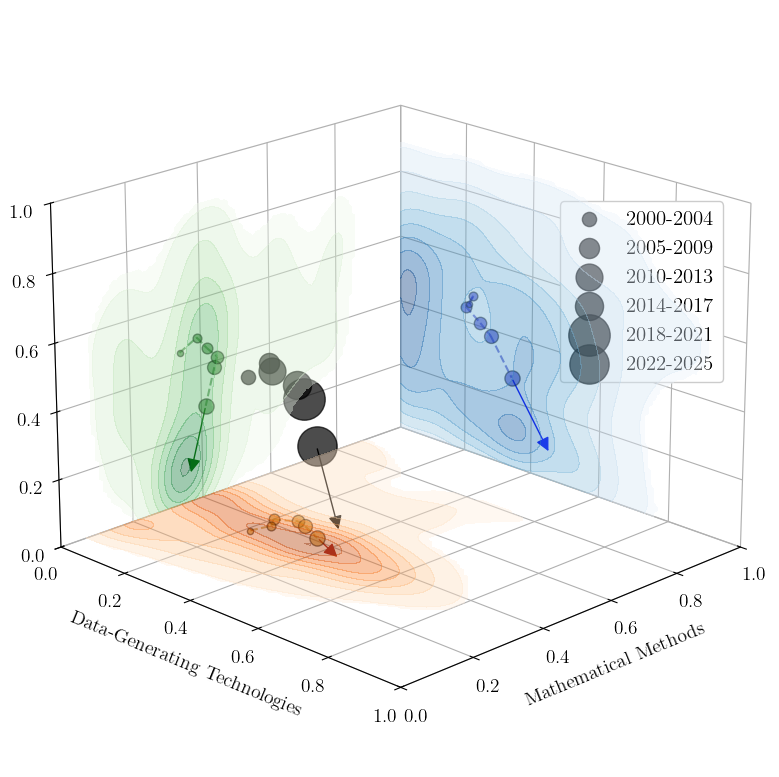

In [74]:
plot_overall_centers_with_projections(dataset, overall_centers)

---
---
## Crop figures

In [76]:
import subprocess
import os

# Crop the summation file
probability_file = "3D_Probability_Density_of_full_dataset_with_trajectories.pdf"
summation_file = "3D_Summation_of_full_dataset_with_trajectories.pdf"

# Path check to ensure files exists before cropping
if os.path.exists(os.path.join(output_dir, probability_file)):
    print(f"Cropping {probability_file} in {output_dir}...")
    subprocess.run(["pdfcrop", probability_file, probability_file], cwd=output_dir)

if os.path.exists(os.path.join(output_dir, summation_file)):
    print(f"Cropping {summation_file} in {output_dir}...")
    subprocess.run(["pdfcrop", summation_file, summation_file], cwd=output_dir)

# Loop through and crop each cluster file
for c in reversed(range(1, cluster_count + 1)):
    file_name = f"3D_Probability_Density_of_Cluster_{c}_with_trajectories.pdf"
    subprocess.run(["pdfcrop", file_name, file_name], cwd=output_dir)
    # Check if file exists to avoid subprocess errors
    if os.path.exists(os.path.join(output_dir, file_name)):
        print(f"Cropping {file_name}...")
        
    else:
        print(f"Warning: {file_name} not found in {output_dir}")

Cropping 3D_Probability_Density_of_full_dataset_with_trajectories.pdf in figures...
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Probability_Density_of_full_dataset_with_trajectories.pdf'.
Cropping 3D_Summation_of_full_dataset_with_trajectories.pdf in figures...
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Summation_of_full_dataset_with_trajectories.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Probability_Density_of_Cluster_4_with_trajectories.pdf'.
Cropping 3D_Probability_Density_of_Cluster_4_with_trajectories.pdf...
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `3D_Probability_Density_of_Cluster_3_with_trajectories.pdf'.
Cropping 3D_Probability_Density_of_C